In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling, Resizing, RandomFlip, RandomRotation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve

2026-05-10 21:50:35.429804: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 21:50:35.449566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-10 21:50:35.471230: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-10 21:50:35.471356: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 21:50:35.490901: I tensorflow/core/platform/cpu_feature_gua

In [2]:
# import os

# train_count = sum(len(files) for _, _, files in os.walk("data/train"))
# val_count = sum(len(files) for _, _, files in os.walk("data/validation"))
# print(f"Train images: {train_count}")   # should be ~11,788
# print(f"Val images:   {val_count}")     # should be ~2,897

# # Check a few class folders
# for cls in os.listdir("data/train")[:5]:
#     n = len(os.listdir(f"data/train/{cls}"))
#     print(f"  class {cls}: {n} images")

In [3]:
X_train = r"/mnt/d/Users/rusha/rusha/Downloads/CUB_200_2011/CUB_200_2011/images"

In [4]:
images = pd.read_csv("/mnt/d/Users/rusha/rusha/Downloads/CUB_200_2011/CUB_200_2011/images.txt", sep=' ', names=['image_id', 'image_name'])
labels = pd.read_csv("/mnt/d/Users/rusha/rusha/Downloads/CUB_200_2011/CUB_200_2011/image_class_labels.txt", sep=' ', names=['image_id', 'class_id'])
split = pd.read_csv("/mnt/d/Users/rusha/rusha/Downloads/CUB_200_2011/CUB_200_2011/train_test_split.txt", sep=' ', names=['image_id', 'is_training_image'])
bboxes = pd.read_csv("/mnt/d/Users/rusha/rusha/Downloads/CUB_200_2011/CUB_200_2011/bounding_boxes.txt", sep=' ', names=['image_id', 'x', 'y', 'width', 'height'])

df = images.merge(labels,on='image_id').merge(split, on='image_id').merge(bboxes, on='image_id')
df.head()

,image_id,image_name,class_id,is_training_image,x,y,width,height
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,60.0,27.0,325.0,304.0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,139.0,30.0,153.0,264.0
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,14.0,112.0,388.0,186.0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,112.0,90.0,255.0,242.0
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,70.0,50.0,134.0,303.0


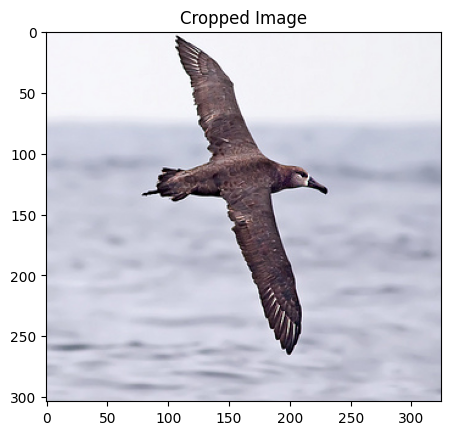

In [5]:
img = mpimg.imread(os.path.join(X_train, df.iloc[1]['image_name']))

x, y, w, h = map(int, df.iloc[0][['x', 'y', 'width', 'height']])
img_cropped = img[y:y+h, x:x+w]

# plt.axis('off')
plt.imshow(img_cropped)
plt.title("Cropped Image")
plt.show()

In [6]:
df = images.merge(labels, on='image_id').merge(bboxes, on='image_id').merge(split, on='image_id')
# df['image_id'] = df['image_name'].apply(lambda name: os.path.join(X_train, name))

In [7]:
train_df = df[df['is_training_image']==1].reset_index(drop=True)
test_df = df[df['is_training_image']==0].reset_index(drop=True)
print(train_df.shape, test_df.shape)

(5994, 8) (5794, 8)


In [8]:
train_df.loc[:,'class_id'] = train_df.loc[:,'class_id'] - 1
test_df.loc[:,'class_id'] = test_df.loc[:,'class_id'] - 1

train_df['image_path'] = train_df['image_name'].apply(lambda name: os.path.join(X_train, name))
test_df['image_path'] = test_df['image_name'].apply(lambda name: os.path.join(X_train, name))

In [10]:
import shutil, os
from PIL import Image

# Step 1: Wipe old data
shutil.rmtree("data", ignore_errors=True)

# Step 2: Save cropped images
def save_images(df, subset_name):
    errors = 0
    for _, row in df.iterrows():
        class_folder = f"data/{subset_name}/{row['class_id']}"
        os.makedirs(class_folder, exist_ok=True)
        try:
            img = Image.open(row['image_path']).convert("RGB")
            x, y, w, h = int(row['x']), int(row['y']), int(row['width']), int(row['height'])
            img_w, img_h = img.size
            x2 = min(x + w, img_w)
            y2 = min(y + h, img_h)
            img_cropped = img.crop((x, y, x2, y2))
            img_cropped.save(os.path.join(class_folder, os.path.basename(row['image_path'])))
        except Exception as e:
            errors += 1
            print(f"Error: {e} | {row['image_path']}")
    print(f"{subset_name} done. Total errors: {errors}")

save_images(train_df, "train")
save_images(test_df, "validation")

# Step 3: Verify
train_count = sum(len(files) for _, _, files in os.walk("data/train"))
val_count   = sum(len(files) for _, _, files in os.walk("data/validation"))
print(f"Train images: {train_count}")   # should be 5994
print(f"Val images:   {val_count}")     # should be 5794

train done. Total errors: 0
validation done. Total errors: 0
Train images: 5994
Val images:   5794


In [11]:
IMG_SIZE = 224

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE,IMG_SIZE])
    return image, label

In [12]:
train_ds = keras.utils.image_dataset_from_directory(
    "data/train",
    label_mode='int',
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
)

validation_ds = keras.utils.image_dataset_from_directory(
    "data/validation",
    label_mode='int',
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
)

Found 5994 files belonging to 200 classes.


2026-05-10 21:52:37.224822: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 21:52:37.238653: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 21:52:37.238723: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 21:52:37.239993: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 21:52:37.240037: I external/local_xla/xla/stream_executor

Found 5794 files belonging to 200 classes.


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess = tf.keras.applications.efficientnet_v2.preprocess_input  # handles normalization

augment = tf.keras.Sequential([
    # tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

def train_preprocess(x, y):
    x = augment(x, training=True)
    x = preprocess(x)       # ← same preprocessing as ImageNet training
    return x, y

def val_preprocess(x, y):
    x = preprocess(x)       # ← same preprocessing, NO augmentation
    return x, y


train_ds = train_ds.map(train_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
validation_ds = validation_ds.map(val_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [15]:
from tensorflow.keras.applications import EfficientNetV2S

conv_base = EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

In [ ]:
# conv_base.summary()

In [16]:
model = Sequential([
    conv_base,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-3)),
    Dropout(0.5),
    Dense(200, activation='softmax')
])

In [ ]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True)


# Phase 1: Train head only (5 epochs)
conv_base.trainable = False
model.compile(optimizer=Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_ds, validation_data=validation_ds, epochs=5,
          callbacks=[lr_scheduler, early_stop])

Epoch 1/5


I0000 00:00:1778430234.153120   16173 service.cc:145] XLA service 0x73852c0038b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778430234.153174   16173 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-05-10 21:53:55.108146: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-10 21:53:57.441909: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1778430296.383280   16173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


188/188 ━━━━━━━━━━━━━━━━━━━━ 198s 635ms/step - accuracy: 0.0792 - loss: 4.9698 - val_accuracy: 0.2934 - val_loss: 3.4765 - learning_rate: 0.0010
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 50s 266ms/step - accuracy: 0.2267 - loss: 3.5850 - val_accuracy: 0.4518 - val_loss: 2.6567 - learning_rate: 0.0010
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 52s 278ms/step - accuracy: 0.3160 - loss: 3.0780 - val_accuracy: 0.5314 - val_loss: 2.3256 - learning_rate: 0.0010
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 53s 282ms/step - accuracy: 0.3677 - loss: 2.7869 - val_accuracy: 0.5632 - val_loss: 2.1614 - learning_rate: 0.0010
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 53s 281ms/step - accuracy: 0.4094 - loss: 2.6473 - val_accuracy: 0.5794 - val_loss: 2.0489 - learning_rate: 0.0010


In [18]:
# Phase 2: Unfreeze top layers and fine-tune
conv_base.trainable = True
for layer in conv_base.layers[:-50]:   # freeze all but last 50 layers
    layer.trainable = False

model.compile(optimizer=Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history2 = model.fit(train_ds, validation_data=validation_ds, epochs=20,
                     callbacks=[lr_scheduler, early_stop])

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 207s 605ms/step - accuracy: 0.4683 - loss: 2.4557 - val_accuracy: 0.6603 - val_loss: 1.7980 - learning_rate: 1.0000e-04
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 54s 285ms/step - accuracy: 0.5075 - loss: 2.2395 - val_accuracy: 0.6899 - val_loss: 1.6347 - learning_rate: 1.0000e-04
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 305ms/step - accuracy: 0.5522 - loss: 2.0677 - val_accuracy: 0.7014 - val_loss: 1.5541 - learning_rate: 1.0000e-04
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 60s 317ms/step - accuracy: 0.5666 - loss: 1.9671 - val_accuracy: 0.7271 - val_loss: 1.4599 - learning_rate: 1.0000e-04
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 59s 310ms/step - accuracy: 0.5963 - loss: 1.8577 - val_accuracy: 0.7354 - val_loss: 1.4147 - learning_rate: 1.0000e-04
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 301ms/step - accuracy: 0.6136 - loss: 1.7869 - val_accuracy: 0.7456 - val_loss: 1.3535 - learning_rate: 1.0000e-04
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 3

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,160,570 (107.42 MB)

 Trainable params: 3,724,936 (14.21 MB)

 Non-trainable params: 16,985,760 (64.80 MB)

 Optimizer params: 7,449,874 (28.42 MB)

In [22]:
# Full evaluation on entire validation set
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get all predictions on validation set
all_preds = []
all_labels = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
top1_acc = np.mean(all_preds == all_labels)
print(f"Top-1 Accuracy: {top1_acc*100:.2f}%")

# Top-5 accuracy (more meaningful for 200 classes)
all_probs = []
for images, labels in validation_ds:
    probs = model.predict(images, verbose=0)
    all_probs.extend(probs)

all_probs = np.array(all_probs)
top5_preds = np.argsort(all_probs, axis=1)[:, -5:]
top5_acc = np.mean([all_labels[i] in top5_preds[i] for i in range(len(all_labels))])
print(f"Top-5 Accuracy: {top5_acc*100:.2f}%")

# Per-class accuracy — find best and worst classes
per_class_acc = {}
for cls in range(200):
    mask = all_labels == cls
    if mask.sum() > 0:
        per_class_acc[cls] = np.mean(all_preds[mask] == cls)

sorted_classes = sorted(per_class_acc.items(), key=lambda x: x[1])

print("\n--- 5 Hardest Classes ---")
for cls_id, acc in sorted_classes[:5]:
    print(f"  {class_names[cls_id]}: {acc*100:.1f}%")

print("\n--- 5 Easiest Classes ---")
for cls_id, acc in sorted_classes[-5:]:
    print(f"  {class_names[cls_id]}: {acc*100:.1f}%")

2026-05-10 23:09:46.155987: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Top-1 Accuracy: 81.10%


2026-05-10 23:10:36.853073: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Top-5 Accuracy: 96.58%

--- 5 Hardest Classes ---


KeyError: 154

In [25]:
# Step 1: Write classes.txt directly from the content we already have
classes_content = """1 001.Black_footed_Albatross
2 002.Laysan_Albatross
3 003.Sooty_Albatross
4 004.Groove_billed_Ani
5 005.Crested_Auklet
6 006.Least_Auklet
7 007.Parakeet_Auklet
8 008.Rhinoceros_Auklet
9 009.Brewer_Blackbird
10 010.Red_winged_Blackbird
11 011.Rusty_Blackbird
12 012.Yellow_headed_Blackbird
13 013.Bobolink
14 014.Indigo_Bunting
15 015.Lazuli_Bunting
16 016.Painted_Bunting
17 017.Cardinal
18 018.Spotted_Catbird
19 019.Gray_Catbird
20 020.Yellow_breasted_Chat
21 021.Eastern_Towhee
22 022.Chuck_will_Widow
23 023.Brandt_Cormorant
24 024.Red_faced_Cormorant
25 025.Pelagic_Cormorant
26 026.Bronzed_Cowbird
27 027.Shiny_Cowbird
28 028.Brown_Creeper
29 029.American_Crow
30 030.Fish_Crow
31 031.Black_billed_Cuckoo
32 032.Mangrove_Cuckoo
33 033.Yellow_billed_Cuckoo
34 034.Gray_crowned_Rosy_Finch
35 035.Purple_Finch
36 036.Northern_Flicker
37 037.Acadian_Flycatcher
38 038.Great_Crested_Flycatcher
39 039.Least_Flycatcher
40 040.Olive_sided_Flycatcher
41 041.Scissor_tailed_Flycatcher
42 042.Vermilion_Flycatcher
43 043.Yellow_bellied_Flycatcher
44 044.Frigatebird
45 045.Northern_Fulmar
46 046.Gadwall
47 047.American_Goldfinch
48 048.European_Goldfinch
49 049.Boat_tailed_Grackle
50 050.Eared_Grebe
51 051.Horned_Grebe
52 052.Pied_billed_Grebe
53 053.Western_Grebe
54 054.Blue_Grosbeak
55 055.Evening_Grosbeak
56 056.Pine_Grosbeak
57 057.Rose_breasted_Grosbeak
58 058.Pigeon_Guillemot
59 059.California_Gull
60 060.Glaucous_winged_Gull
61 061.Heermann_Gull
62 062.Herring_Gull
63 063.Ivory_Gull
64 064.Ring_billed_Gull
65 065.Slaty_backed_Gull
66 066.Western_Gull
67 067.Anna_Hummingbird
68 068.Ruby_throated_Hummingbird
69 069.Rufous_Hummingbird
70 070.Green_Violetear
71 071.Long_tailed_Jaeger
72 072.Pomarine_Jaeger
73 073.Blue_Jay
74 074.Florida_Jay
75 075.Green_Jay
76 076.Dark_eyed_Junco
77 077.Tropical_Kingbird
78 078.Gray_Kingbird
79 079.Belted_Kingfisher
80 080.Green_Kingfisher
81 081.Pied_Kingfisher
82 082.Ringed_Kingfisher
83 083.White_breasted_Kingfisher
84 084.Red_legged_Kittiwake
85 085.Horned_Lark
86 086.Pacific_Loon
87 087.Mallard
88 088.Western_Meadowlark
89 089.Hooded_Merganser
90 090.Red_breasted_Merganser
91 091.Mockingbird
92 092.Nighthawk
93 093.Clark_Nutcracker
94 094.White_breasted_Nuthatch
95 095.Baltimore_Oriole
96 096.Hooded_Oriole
97 097.Orchard_Oriole
98 098.Scott_Oriole
99 099.Ovenbird
100 100.Brown_Pelican
101 101.White_Pelican
102 102.Western_Wood_Pewee
103 103.Sayornis
104 104.American_Pipit
105 105.Whip_poor_Will
106 106.Horned_Puffin
107 107.Common_Raven
108 108.White_necked_Raven
109 109.American_Redstart
110 110.Geococcyx
111 111.Loggerhead_Shrike
112 112.Great_Grey_Shrike
113 113.Baird_Sparrow
114 114.Black_throated_Sparrow
115 115.Brewer_Sparrow
116 116.Chipping_Sparrow
117 117.Clay_colored_Sparrow
118 118.House_Sparrow
119 119.Field_Sparrow
120 120.Fox_Sparrow
121 121.Grasshopper_Sparrow
122 122.Harris_Sparrow
123 123.Henslow_Sparrow
124 124.Le_Conte_Sparrow
125 125.Lincoln_Sparrow
126 126.Nelson_Sharp_tailed_Sparrow
127 127.Savannah_Sparrow
128 128.Seaside_Sparrow
129 129.Song_Sparrow
130 130.Tree_Sparrow
131 131.Vesper_Sparrow
132 132.White_crowned_Sparrow
133 133.White_throated_Sparrow
134 134.Cape_Glossy_Starling
135 135.Bank_Swallow
136 136.Barn_Swallow
137 137.Cliff_Swallow
138 138.Tree_Swallow
139 139.Scarlet_Tanager
140 140.Summer_Tanager
141 141.Artic_Tern
142 142.Black_Tern
143 143.Caspian_Tern
144 144.Common_Tern
145 145.Elegant_Tern
146 146.Forsters_Tern
147 147.Least_Tern
148 148.Green_tailed_Towhee
149 149.Brown_Thrasher
150 150.Sage_Thrasher
151 151.Black_capped_Vireo
152 152.Blue_headed_Vireo
153 153.Philadelphia_Vireo
154 154.Red_eyed_Vireo
155 155.Warbling_Vireo
156 156.White_eyed_Vireo
157 157.Yellow_throated_Vireo
158 158.Bay_breasted_Warbler
159 159.Black_and_white_Warbler
160 160.Black_throated_Blue_Warbler
161 161.Blue_winged_Warbler
162 162.Canada_Warbler
163 163.Cape_May_Warbler
164 164.Cerulean_Warbler
165 165.Chestnut_sided_Warbler
166 166.Golden_winged_Warbler
167 167.Hooded_Warbler
168 168.Kentucky_Warbler
169 169.Magnolia_Warbler
170 170.Mourning_Warbler
171 171.Myrtle_Warbler
172 172.Nashville_Warbler
173 173.Orange_crowned_Warbler
174 174.Palm_Warbler
175 175.Pine_Warbler
176 176.Prairie_Warbler
177 177.Prothonotary_Warbler
178 178.Swainson_Warbler
179 179.Tennessee_Warbler
180 180.Wilson_Warbler
181 181.Worm_eating_Warbler
182 182.Yellow_Warbler
183 183.Northern_Waterthrush
184 184.Louisiana_Waterthrush
185 185.Bohemian_Waxwing
186 186.Cedar_Waxwing
187 187.American_Three_toed_Woodpecker
188 188.Pileated_Woodpecker
189 189.Red_bellied_Woodpecker
190 190.Red_cockaded_Woodpecker
191 191.Red_headed_Woodpecker
192 192.Downy_Woodpecker
193 193.Bewick_Wren
194 194.Cactus_Wren
195 195.Carolina_Wren
196 196.House_Wren
197 197.Marsh_Wren
198 198.Rock_Wren
199 199.Winter_Wren
200 200.Common_Yellowthroat"""

# Step 2: Load into class_names dict
class_names = {}
for line in classes_content.strip().split("\n"):
    parts = line.strip().split(" ", 1)
    if len(parts) == 2:
        idx, name = parts
        class_names[int(idx) - 1] = name  # 0-indexed

print(f"Loaded {len(class_names)} classes")  # should be 200

# Step 3: Print hardest/easiest
print("\n--- 5 Hardest Classes ---")
for cls_id, acc in sorted_classes[:5]:
    print(f"  {class_names.get(cls_id, f'Class {cls_id}')}: {acc*100:.1f}%")

print("\n--- 5 Easiest Classes ---")
for cls_id, acc in sorted_classes[-5:]:
    print(f"  {class_names.get(cls_id, f'Class {cls_id}')}: {acc*100:.1f}%")

Loaded 200 classes

--- 5 Hardest Classes ---
  155.Warbling_Vireo: 16.7%
  120.Fox_Sparrow: 23.3%
  159.Black_and_white_Warbler: 30.0%
  016.Painted_Bunting: 36.7%
  123.Henslow_Sparrow: 36.7%

--- 5 Easiest Classes ---
  153.Philadelphia_Vireo: 100.0%
  167.Hooded_Warbler: 100.0%
  173.Orange_crowned_Warbler: 100.0%
  193.Bewick_Wren: 100.0%
  200.Common_Yellowthroat: 100.0%


In [26]:
def compute_iou_tf(box1, box2):
    box1 = tf.reshape(tf.convert_to_tensor(box1, dtype=tf.float32), [4])
    box2 = tf.reshape(tf.convert_to_tensor(box2, dtype=tf.float32), [4])

    # (x, y, w, h) → (x1, y1, x2, y2)  — CUB boxes are already x,y,w,h format
    x1,  y1  = box1[0],          box1[1]
    x2,  y2  = box1[0]+box1[2],  box1[1]+box1[3]

    x1_gt, y1_gt = box2[0],          box2[1]
    x2_gt, y2_gt = box2[0]+box2[2],  box2[1]+box2[3]

    # Intersection
    xi1 = tf.maximum(x1, x1_gt)
    yi1 = tf.maximum(y1, y1_gt)
    xi2 = tf.minimum(x2, x2_gt)   # ← fixed
    yi2 = tf.minimum(y2, y2_gt)   # ← fixed

    inter_area = tf.maximum(xi2 - xi1, 0.0) * tf.maximum(yi2 - yi1, 0.0)
    box1_area  = (x2 - x1) * (y2 - y1)
    box2_area  = (x2_gt - x1_gt) * (y2_gt - y1_gt)
    union_area = box1_area + box2_area - inter_area

    return inter_area / (union_area + 1e-6)

# Quick test
box1 = [10, 10, 50, 50]   # x, y, w, h
box2 = [30, 30, 50, 50]   # overlapping box
print(f"IoU (overlapping): {compute_iou_tf(box1, box2).numpy():.4f}")  # should be > 0

box3 = [200, 200, 50, 50]  # non-overlapping
print(f"IoU (no overlap):  {compute_iou_tf(box1, box3).numpy():.4f}")  # should be 0.0

IoU (overlapping): 0.2195
IoU (no overlap):  0.0000


In [27]:
# Predict in batches — safe for limited GPU memory
y_scores = model.predict(validation_ds, verbose=1)
y_pred   = np.argmax(y_scores, axis=1)

# Get true labels from validation_ds
y_test = np.concatenate([labels.numpy() for _, labels in validation_ds])

print(f"y_scores shape: {y_scores.shape}")   # (5794, 200)
print(f"y_test shape:   {y_test.shape}")     # (5794,)
print(f"y_pred shape:   {y_pred.shape}")     # (5794,)

182/182 ━━━━━━━━━━━━━━━━━━━━ 65s 284ms/step
y_scores shape: (5794, 200)
y_test shape:   (5794,)
y_pred shape:   (5794,)


2026-05-10 23:16:44.051468: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Macro-average AUC: 0.9975


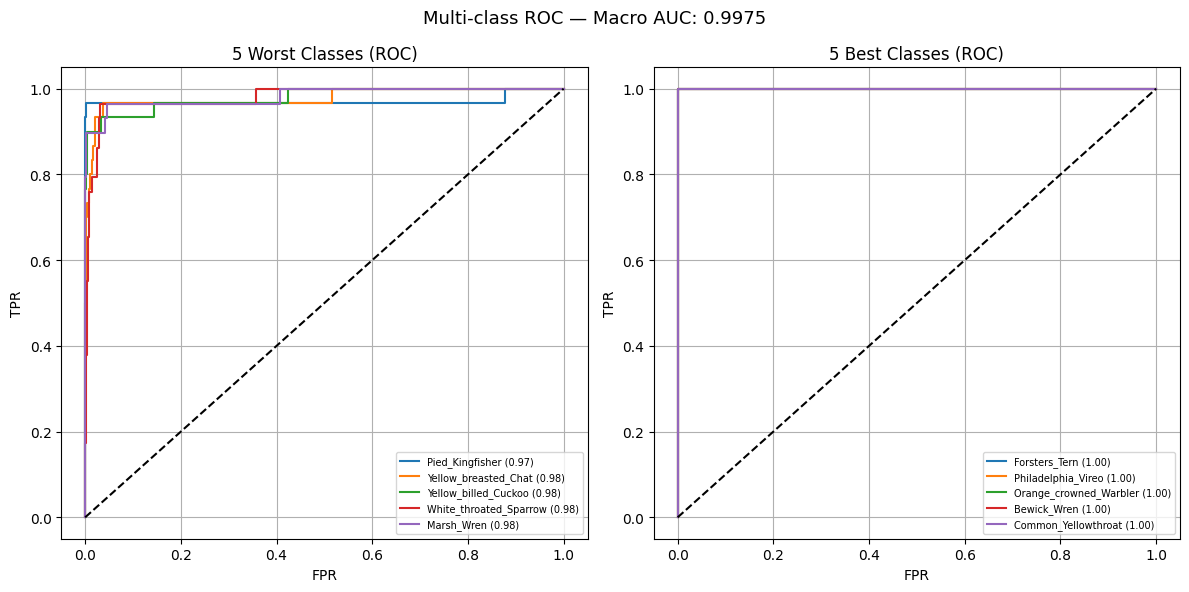

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Step 1: Get predictions and true labels (use already computed values)
# y_scores shape: (5794, 200)
# y_test  shape: (5794,)

# Step 2: Binarize true labels for all 200 classes
y_true_bin = label_binarize(y_test, classes=list(range(200)))  # (5794, 200)

# Step 3: Compute macro-average ROC (one curve summarizing all 200 classes)
fpr_all = {}
tpr_all = {}
roc_auc_all = {}

for i in range(200):
    fpr_all[i], tpr_all[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc_all[i] = auc(fpr_all[i], tpr_all[i])

# Macro average AUC
mean_auc = np.mean(list(roc_auc_all.values()))
print(f"Macro-average AUC: {mean_auc:.4f}")

# Step 4: Plot top 5 best and worst classes + macro average
sorted_by_auc = sorted(roc_auc_all.items(), key=lambda x: x[1])
worst_5 = sorted_by_auc[:5]
best_5  = sorted_by_auc[-5:]

plt.figure(figsize=(12, 6))

# Worst classes
plt.subplot(1, 2, 1)
for cls_id, cls_auc in worst_5:
    label = class_names.get(cls_id, f"Class {cls_id}").split(".")[-1]
    plt.plot(fpr_all[cls_id], tpr_all[cls_id], label=f"{label} ({cls_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("5 Worst Classes (ROC)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(fontsize=7, loc='lower right')
plt.grid(True)

# Best classes
plt.subplot(1, 2, 2)
for cls_id, cls_auc in best_5:
    label = class_names.get(cls_id, f"Class {cls_id}").split(".")[-1]
    plt.plot(fpr_all[cls_id], tpr_all[cls_id], label=f"{label} ({cls_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("5 Best Classes (ROC)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(fontsize=7, loc='lower right')
plt.grid(True)

plt.suptitle(f"Multi-class ROC — Macro AUC: {mean_auc:.4f}", fontsize=13)
plt.tight_layout()
plt.show()